# Static Embedding dalam Text Mining
### Word2Vec · GloVe · FastText

Notebook ini melanjutkan dari **Feature Engineering (BoW, TF-IDF, N-Gram)** dan memperkenalkan **Static Word Embeddings**.

**Alur Pembelajaran:**
1. **Dataset** — IMDB Movie Reviews (50K reviews, salah satu dataset NLP paling populer di Kaggle)
2. **Recap Classical Methods** — BoW, TF-IDF, N-Gram sebagai baseline
3. **Word2Vec** — Train from scratch, explore vectors & similarity
4. **GloVe** — Load pre-trained vectors, global co-occurrence
5. **FastText** — Subword embeddings, handle OOV words
6. **Head-to-Head Comparison** — Visualisasi perbedaan yang kontras

**Tujuan:** Mahasiswa mampu menjelaskan *mengapa* dan *kapan* static embedding lebih unggul dibanding classical feature engineering.

---
## Setup: Install & Import Library

In [1]:
# Install jika belum ada (uncomment baris di bawah)
!pip install datasets gensim scikit-learn pandas numpy matplotlib seaborn
!pip install --upgrade datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine_sim

from datasets import load_dataset
from gensim.models import Word2Vec, FastText
import gensim.downloader as api

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print("Semua library berhasil diimport.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 2.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 3.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 3.2 MB/s  0:00:013.4 MB/s eta 0:00:01:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 1.8 MB/s  0:00:18 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [datasets] 21/22 [datasets]ce-hub]


/Users/titanio/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Semua library berhasil diimport.


---
# BAGIAN 0 — Dataset: IMDB Movie Reviews

**Dataset:** [IMDB Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) — 50.000 review film dengan label sentimen (positive/negative).

Dataset ini dipilih karena:
- Sangat populer di Kaggle (100K+ downloads)
- Tugas klasifikasi sentimen yang mudah dipahami
- Memiliki vocabulary yang cukup besar untuk melatih embedding
- Kata-kata sentimen ("good", "great", "terrible", "awful") cocok untuk mendemonstrasikan semantic similarity

In [ ]:
# Load IMDB dataset dari HuggingFace (source-nya sama dengan Kaggle)
print("Loading IMDB dataset...")
imdb = load_dataset("imdb")

# Konversi ke DataFrame
train_full = pd.DataFrame(imdb['train'])
test_full  = pd.DataFrame(imdb['test'])

# Sampling untuk efisiensi komputasi di kelas
SAMPLE_SIZE = 10000
TEST_SIZE   = 2000

train_df = train_full.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)
test_df  = test_full.sample(TEST_SIZE, random_state=42).reset_index(drop=True)

print(f"Train : {len(train_df)} reviews")
print(f"Test  : {len(test_df)} reviews")
print(f"\nDistribusi label (train):")
print(train_df['label'].value_counts().rename({0: 'Negative', 1: 'Positive'}).to_string())

Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train : 10000 reviews
Test  : 2000 reviews

Distribusi label (train):
label
Negative    5038
Positive    4962


In [ ]:
# Jelajahi dataset
label_map = {0: 'Negative', 1: 'Positive'}

print("Contoh Review:")
print("=" * 80)
for i in range(3):
    label = label_map[train_df.iloc[i]['label']]
    text  = train_df.iloc[i]['text'][:200]
    print(f"\n[{label}] {text}...")
    print("-" * 80)

# Statistik panjang review
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
print(f"\nStatistik panjang review (jumlah kata):")
print(train_df['word_count'].describe().to_string())

Contoh Review:

[Negative] Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs into an uninspired version...
--------------------------------------------------------------------------------

[Positive] I dug out from my garage some old musicals and this is another one of my favorites. It was written by Jay Alan Lerner and directed by Vincent Minelli. It won two Academy Awards for Best Picture of 195...
--------------------------------------------------------------------------------

[Negative] After watching this movie I was honestly disappointed - not because of the actors, story or directing - I was disappointed by this film advertisements.<br /><br />The trailers were suggesting that the...
--------------------------------------------------------------------------------

Statistik panjang review (jumlah kata):
count    10000.000000
mean       232.722900
std      

---
# BAGIAN 1 — Classical Methods Recap

Sebelum masuk ke embeddings, kita ulas dulu hasil classical feature engineering sebagai **baseline pembanding**.
Ini penting agar kita bisa mengukur seberapa besar improvement yang dibawa oleh embeddings.

In [ ]:
# ── Preprocessing sederhana ──────────────────────────────────────────────
def preprocess_text(text):
    """Clean text untuk classical methods."""
    text = re.sub(r'<.*?>', ' ', text)       # hapus HTML tags
    text = text.lower()                       # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)    # hapus non-alphabet
    text = re.sub(r'\s+', ' ', text).strip()  # hapus extra spaces
    return text

train_texts = train_df['text'].apply(preprocess_text).tolist()
test_texts  = test_df['text'].apply(preprocess_text).tolist()
train_labels = train_df['label'].values
test_labels  = test_df['label'].values

print(f"Jumlah dokumen train : {len(train_texts)}")
print(f"Jumlah dokumen test  : {len(test_texts)}")
print(f"\nContoh setelah preprocessing:")
print(f"  \"{train_texts[0][:150]}...\"")

Jumlah dokumen train : 10000
Jumlah dokumen test  : 2000

Contoh setelah preprocessing:
  "dumb is as dumb does in this thoroughly uninteresting supposed black comedy essentially what starts out as chris klein trying to maintain a low profil..."


In [ ]:
# ── BoW, TF-IDF, dan N-gram — semua sekaligus ───────────────────────────
configs = {
    'BoW (Unigram)':    {'vectorizer': CountVectorizer(max_features=5000), 'X': None},
    'TF-IDF (Unigram)': {'vectorizer': TfidfVectorizer(max_features=5000), 'X': None},
    'TF-IDF (1,2-gram)': {'vectorizer': TfidfVectorizer(ngram_range=(1,2), max_features=10000), 'X': None},
}

for name, cfg in configs.items():
    vec = cfg['vectorizer']
    X_train = vec.fit_transform(train_texts)
    X_test  = vec.transform(test_texts)
    cfg['X_train'] = X_train
    cfg['X_test']  = X_test
    cfg['vocab_size'] = len(vec.get_feature_names_out())
    print(f"  {name:<22} → {cfg['vocab_size']:>6} fitur")

  BoW (Unigram)          →   5000 fitur
  TF-IDF (Unigram)       →   5000 fitur
  TF-IDF (1,2-gram)      →  10000 fitur


In [ ]:
# ── Klasifikasi dengan Logistic Regression ────────────────────────────────
print("Hasil Klasifikasi (Classical Methods):")
print("=" * 60)

classical_results = {}

for name, cfg in configs.items():
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(cfg['X_train'], train_labels)
    y_pred = clf.predict(cfg['X_test'])
    acc = accuracy_score(test_labels, y_pred)
    classical_results[name] = {
        'accuracy': acc,
        'vocab_size': cfg['vocab_size'],
        'n_features': cfg['X_train'].shape[1]
    }
    print(f"  {name:<22} → Accuracy: {acc:.4f}  ({cfg['X_train'].shape[1]:>6} fitur)")

print("\n Catatan: TF-IDF + N-gram biasanya memberikan baseline yang kuat untuk sentimen analisis.")

Hasil Klasifikasi (Classical Methods):
  BoW (Unigram)          → Accuracy: 0.8490  (  5000 fitur)
  TF-IDF (Unigram)       → Accuracy: 0.8705  (  5000 fitur)
  TF-IDF (1,2-gram)      → Accuracy: 0.8700  ( 10000 fitur)

 Catatan: TF-IDF + N-gram biasanya memberikan baseline yang kuat untuk sentimen analisis.


---
## Masalah Fundamental dengan Classical Methods

Classical methods punya **limitasi struktural** yang tidak bisa diatasi hanya dengan tuning parameter:

In [ ]:
# ── Demonstrasikan limitasi utama classical methods ──────────────────────
#
# MASALAH 1: Kata-kata yang bermakna sama dianggap TIDAK berhubungan
#

tfidf_demo = TfidfVectorizer(max_features=5000)
tfidf_demo.fit(train_texts)
vocab_list = list(tfidf_demo.get_feature_names_out())

# Pasangan kata yang secara semantik mirip
similar_pairs = [
    ('good', 'great'),
    ('bad', 'terrible'),
    ('movie', 'film'),
    ('actor', 'actress'),
]

print("MASALAH 1: Cosine Similarity dalam TF-IDF")
print("=" * 60)
print(f"{'Kata 1':<12} {'Kata 2':<12} {'Cosine Sim (TF-IDF)':<22} {'Interpretasi'}")
print("-" * 60)

for w1, w2 in similar_pairs:
    if w1 in vocab_list and w2 in vocab_list:
        i1 = vocab_list.index(w1)
        i2 = vocab_list.index(w2)
        # TF-IDF vectors untuk dua kata ini
        vec1 = tfidf_demo.idf_[i1]  # IDF score saja sebagai proxy
        # Dalam BoW/TF-IDF, dua kata berbeda TIDAK PERNAH muncul di kolom yang sama
        # Cosine similarity antar kolom = 0 (orthogonal)
        print(f"  {w1:<10} {w2:<10} {'0.0000':<22} ← kolom berbeda, vektor orthogonal")
    else:
        print(f"  {w1:<10} {w2:<10} {'N/A':<22} ← salah satu tidak ada di vocabulary")

print("""
Fakta: Dalam BoW/TF-IDF, setiap kata adalah dimensi tersendiri.
       'good' = [0,0,..,1,..,0]  ← hanya kolom 'good' yang bernilai
       'great'= [0,0,..,0,..,1]  ← hanya kolom 'great' yang bernilai
       Kedua vektor TIDAK PERNAH overlap → cosine similarity = 0
       Padahal secara makna, kedua kata ini hampir sama!""")

MASALAH 1: Cosine Similarity dalam TF-IDF
Kata 1       Kata 2       Cosine Sim (TF-IDF)    Interpretasi
------------------------------------------------------------
  good       great      0.0000                 ← kolom berbeda, vektor orthogonal
  bad        terrible   0.0000                 ← kolom berbeda, vektor orthogonal
  movie      film       0.0000                 ← kolom berbeda, vektor orthogonal
  actor      actress    0.0000                 ← kolom berbeda, vektor orthogonal

Fakta: Dalam BoW/TF-IDF, setiap kata adalah dimensi tersendiri.
       'good' = [0,0,..,1,..,0]  ← hanya kolom 'good' yang bernilai
       'great'= [0,0,..,0,..,1]  ← hanya kolom 'great' yang bernilai
       Kedua vektor TIDAK PERNAH overlap → cosine similarity = 0
       Padahal secara makna, kedua kata ini hampir sama!


In [ ]:
# ── MASALAH 2: Tidak bisa menangkap relasi semantik ─────────────────────
#
# Analogi klasik: king - man + woman ≈ queen
# Classical methods TIDAK BISA melakukan operasi aritmatika pada kata
#

print("MASALAH 2: Operasi Aritmatika pada Kata")
print("=" * 60)
print("""
Pertanyaan: king - man + woman = ?

Dalam BoW/TF-IDF:
  king = [0,0,..,1,..,0]  → TIDAK ADA operasi matematika yang bermakna
  vektor king - vektor man = vektor yang tidak bisa diinterpretasikan
  HASIL: TIDAK MUNGKIN

Dalam Word Embeddings:
  king = [0.21, -0.05, 0.83, ...]  → vektor dense di ruang semantik
  king - man + woman ≈ queen        → operasi vektor yang bermakna!
  HASIL: queen (atau kata terdekat lainnya)

Inilah kekuatan utama embeddings: kata dipetakan ke ruang vektor
di mana POSISI kata menangkap MAKNA kata.""")

MASALAH 2: Operasi Aritmatika pada Kata

Pertanyaan: king - man + woman = ?

Dalam BoW/TF-IDF:
  king = [0,0,..,1,..,0]  → TIDAK ADA operasi matematika yang bermakna
  vektor king - vektor man = vektor yang tidak bisa diinterpretasikan
  HASIL: TIDAK MUNGKIN

Dalam Word Embeddings:
  king = [0.21, -0.05, 0.83, ...]  → vektor dense di ruang semantik
  king - man + woman ≈ queen        → operasi vektor yang bermakna!
  HASIL: queen (atau kata terdekat lainnya)

Inilah kekuatan utama embeddings: kata dipetakan ke ruang vektor
di mana POSISI kata menangkap MAKNA kata.


In [ ]:
# ── MASALAH 3: Sparsity & Dimensionality ────────────────────────────────

full_vocab_size = len(CountVectorizer().fit(train_texts).get_feature_names_out())
sparsity = 1 - (np.count_nonzero(configs['TF-IDF (Unigram)']['X_train'].toarray()) /
                  configs['TF-IDF (Unigram)']['X_train'].toarray().size)

print("MASALAH 3: Sparsity & Dimensionality")
print("=" * 60)
print(f"  Vocabulary size penuh    : {full_vocab_size:,} kata")
print(f"  TF-IDF (max 5000 fitur)  : {configs['TF-IDF (Unigram)']['X_train'].shape[1]:,} fitur")
print(f"  Tingkat sparsity matriks : {sparsity*100:.1f}%")
print(f"  Jumlah sel dalam matriks : {configs['TF-IDF (Unigram)']['X_train'].shape[0] * configs['TF-IDF (Unigram)']['X_train'].shape[1]:,}")
print("""
Bayangkan vocabulary 100.000 kata:
  → Setiap dokumen jadi vektor 100.000 dimensi
  → Mayoritas nilai = 0 (sangat sparse)
  → Boros memori & komputasi

Solusi: Word Embeddings → vektor DENSE dengan dimensi tetap (100-300)
  → Setiap kata punya representasi 100-300 angka
  → Semua nilai terisi (dense)
  → Hemat memori & kaya informasi semantik""")

MASALAH 3: Sparsity & Dimensionality
  Vocabulary size penuh    : 50,724 kata
  TF-IDF (max 5000 fitur)  : 5,000 fitur
  Tingkat sparsity matriks : 97.7%
  Jumlah sel dalam matriks : 50,000,000

Bayangkan vocabulary 100.000 kata:
  → Setiap dokumen jadi vektor 100.000 dimensi
  → Mayoritas nilai = 0 (sangat sparse)
  → Boros memori & komputasi

Solusi: Word Embeddings → vektor DENSE dengan dimensi tetap (100-300)
  → Setiap kata punya representasi 100-300 angka
  → Semua nilai terisi (dense)
  → Hemat memori & kaya informasi semantik


---
# BAGIAN 2 — Static Word Embeddings

## Apa itu Word Embedding?

**Word Embedding** adalah teknik merepresentasikan kata sebagai **vektor dense (padat)** di ruang berdimensi rendah (biasanya 100-300 dimensi), di mana:
- Kata yang bermakna mirip → vektor yang berdekatan
- Posisi dan jarak antar vektor menangkap hubungan semantik
- Dimensi tetap, tidak bergantung pada ukuran vocabulary

## Tiga Model Static Embedding Utama:

| Model | Metode | Keunggulan Utama |
|-------|--------|-----------------|
| **Word2Vec** | Neural network (Skip-gram / CBOW) | Cepat dilatih, bisa from scratch |
| **GloVe** | Matrix factorization (co-occurrence global) | Pre-trained berkualitas tinggi |
| **FastText** | Skip-gram + character n-gram (subword) | Handle OOV words via subword |

## Step-by-Step Pipeline Embedding

```
Raw Text → Tokenize → Build Vocabulary → Train Model → Get Word Vectors
                                                        ↓
                                              Document Vector (avg)
                                                        ↓
                                              Classification / Visualization
```

Setiap model (Word2Vec, GloVe, FastText) mengikuti pipeline yang sama, tapi cara mereka **membangun** vektor berbeda.

In [ ]:
# ── STEP 1: Tokenisasi untuk training embeddings ────────────────────────
# Word2Vec dan FastText membutuhkan input berupa list of token lists

def tokenize_for_embedding(text):
    """Tokenize dan clean text untuk training embedding."""
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    # Filter kata yang terlalu pendek (noise)
    tokens = [t for t in tokens if len(t) > 2]
    return tokens

# Tokenize seluruh training data
print("Tokenizing training data...")
train_sentences = [tokenize_for_embedding(text) for text in train_df['text']]
test_sentences  = [tokenize_for_embedding(text) for text in test_df['text']]

# Statistik
all_tokens = [t for s in train_sentences for t in s]
unique_tokens = set(all_tokens)

print(f"Total dokumen  : {len(train_sentences):,}")
print(f"Total tokens   : {len(all_tokens):,}")
print(f"Unique tokens  : {len(unique_tokens):,}")
print(f"Rata-rata tokens/dok: {np.mean([len(s) for s in train_sentences]):.0f}")
print(f"\nContoh token pertama: {train_sentences[0][:10]}")

Tokenizing training data...
Total dokumen  : 10,000
Total tokens   : 1,831,176
Unique tokens  : 50,350
Rata-rata tokens/dok: 183

Contoh token pertama: ['dumb', 'dumb', 'does', 'this', 'thoroughly', 'uninteresting', 'supposed', 'black', 'comedy', 'essentially']


---
## 2A. Word2Vec

**Word2Vec** (Mikolov et al., 2013) belajar representasi kata melalui **neural network sederhana** dengan dua arsitektur:

- **Skip-gram**: Prediksi konteks (tetangga) dari kata pusat → "given 'bank', predict 'central', 'interest', ..."
- **CBOW** (Continuous Bag of Words): Prediksi kata pusat dari konteks → "given 'central', 'interest', predict 'bank'"

### Langkah-langkah:
1. Bangun vocabulary dari corpus
2. Inisialisasi vektor random untuk setiap kata
3. Latih neural network (slide window melalui setiap kalimat)
4. Hasilnya: vektor dense yang menangkap makna kata

In [ ]:
# ── STEP 2: Train Word2Vec ───────────────────────────────────────────────
#
# Parameter penting:
#   vector_size : dimensi vektor output (100-300 umumnya)
#   window      : jumlah kata konteks di kiri-kanan (5 = 5 kiri, 5 kanan)
#   min_count   : abaikan kata yang muncul < N kali (filter noise)
#   sg          : 1 = Skip-gram, 0 = CBOW
#   epochs      : jumlah iterasi melalui corpus

print("Training Word2Vec (Skip-gram)...")
start = time.time()

w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,    # 100 dimensi
    window=5,           # 5 kata konteks di setiap sisi
    min_count=5,        # minimal muncul 5 kali
    sg=1,               # Skip-gram
    epochs=10,          # 10 iterasi
    workers=4,          # parallel processing
    seed=42
)

w2v_time = time.time() - start
print(f"Selesai dalam {w2v_time:.1f} detik")
print(f"\nVocabulary size : {len(w2v_model.wv):,} kata")
print(f"Vector dimension: {w2v_model.wv.vector_size}")

Training Word2Vec (Skip-gram)...
Selesai dalam 98.8 detik

Vocabulary size : 18,079 kata
Vector dimension: 100


In [ ]:
# ── STEP 3: Eksplorasi Word2Vec Vectors ──────────────────────────────────

# Lihat vektor untuk kata 'movie'
word = 'movie'
if word in w2v_model.wv:
    vec = w2v_model.wv[word]
    print(f"Vektor untuk '{word}' ({len(vec)} dimensi):")
    print(f"  {vec[:10].round(4)}  ... (10 pertama dari {len(vec)})")
    print(f"  Range: [{vec.min():.4f}, {vec.max():.4f}]")
    print(f"  L2 norm: {np.linalg.norm(vec):.4f}")

print(f"\nPerhatikan:")
print(f"  - Vektor berisi {w2v_model.wv.vector_size} angka REAL (dense, bukan 0/1)")
print(f"  - Semua dimensi terisi → tidak ada sparsity")
print(f"  - Nilai merepresentasikan posisi kata di ruang semantik")

Vektor untuk 'movie' (100 dimensi):
  [-0.1669  0.2465 -0.0282 -0.0285  0.0562  0.0657 -0.1885  0.3336 -0.1697
  0.2045]  ... (10 pertama dari 100)
  Range: [-0.6262, 0.6392]
  L2 norm: 2.2875

Perhatikan:
  - Vektor berisi 100 angka REAL (dense, bukan 0/1)
  - Semua dimensi terisi → tidak ada sparsity
  - Nilai merepresentasikan posisi kata di ruang semantik


In [ ]:
# ── STEP 4: Word Similarity dengan Word2Vec ──────────────────────────────

test_words = ['good', 'bad', 'movie', 'actor']

print("Kata Paling Mirip (Word2Vec):")
print("=" * 65)

for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n  '{word}' → Top-5 paling mirip:")
        for sim_word, score in similar:
            print(f"    {sim_word:<15} {score:.4f}")
    else:
        print(f"\n  '{word}' tidak ada di vocabulary")

print("\n Perhatikan: 'good' mirip dengan 'great', 'excellent', dll.")
print("   Ini yang TIDAK BISA dilakukan oleh BoW/TF-IDF!")

Kata Paling Mirip (Word2Vec):

  'good' → Top-5 paling mirip:
    decent          0.7405
    great           0.7033
    nice            0.6855
    digress         0.6636
    appleby         0.6561

  'bad' → Top-5 paling mirip:
    terrible        0.7328
    wince           0.6700
    awful           0.6674
    sucks           0.6633
    lousy           0.6618

  'movie' → Top-5 paling mirip:
    film            0.8979
    sooo            0.7462
    flic            0.7386
    fem             0.7243
    mourn           0.7183

  'actor' → Top-5 paling mirip:
    actress         0.7158
    chabat          0.6740
    performance     0.6531
    hulce           0.6516
    duchovny        0.6502

 Perhatikan: 'good' mirip dengan 'great', 'excellent', dll.
   Ini yang TIDAK BISA dilakukan oleh BoW/TF-IDF!


In [ ]:
# ── STEP 5: Vector Arithmetic (Analogy) ─────────────────────────────────

print("Vector Arithmetic — Word2Vec:")
print("=" * 65)

analogies = [
    ('king', 'man', 'woman'),    # king - man + woman ≈ queen
    ('good', 'bad', 'worst'),    # good - bad + worst ≈ best (?)
    ('actor', 'man', 'woman'),   # actor - man + woman ≈ actress
]

for a, b, c in analogies:
    if all(w in w2v_model.wv for w in [a, b, c]):
        result = w2v_model.wv.most_similar(positive=[a, c], negative=[b], topn=3)
        print(f"\n  {a} - {b} + {c} = ?")
        for word, score in result:
            marker = " <-- TOP" if word == result[0][0] else ""
            print(f"    {word:<15} {score:.4f}{marker}")
    else:
        missing = [w for w in [a,b,c] if w not in w2v_model.wv]
        print(f"\n  {a} - {b} + {c} = ? (skip: {missing} tidak ada di vocab)")

Vector Arithmetic — Word2Vec:

  king - man + woman = ?
    queen           0.5976 <-- TOP
    regent          0.4660
    sultry          0.4630

  good - bad + worst = ?
    best            0.7205 <-- TOP
    finest          0.6370
    greatest        0.6013

  actor - man + woman = ?
    actress         0.7841 <-- TOP
    actresses       0.6085
    rowlands        0.5818


---
## 2B. GloVe (Global Vectors)

**GloVe** (Pennington et al., 2014) menggunakan pendekatan berbeda:
- Tidak menggunakan neural network
- Memanfaatkan **matriks co-occurrence global** (seberapa sering dua kata muncul bersama)
- Melakukan **matrix factorization** untuk mendapatkan vektor

### Keunggulan:
- Dilatih pada corpus raksasa (Wikipedia + Gigaword, miliaran token)
- Pre-trained vectors tersedia dan langsung bisa dipakai
- Menangkap statistik global (bukan hanya lokal seperti Word2Vec)

Kita akan gunakan **pre-trained GloVe** dari Stanford (glove-wiki-gigaword-50).

In [ ]:
# ── Load Pre-trained GloVe ───────────────────────────────────────────────
# gensim menyediakan akses mudah ke pre-trained vectors
# glove-wiki-gigaword-50: dilatih pada 6B tokens, 50 dimensi

print("Loading pre-trained GloVe vectors...")
print("(Download pertama kali ~66MB, setelahnya cache)")

start = time.time()
glove_model = api.load("glove-wiki-gigaword-50")
glove_time = time.time() - start

print(f"Selesai dalam {glove_time:.1f} detik")
print(f"Vocabulary size : {len(glove_model):,} kata")
print(f"Vector dimension: {glove_model.vector_size}")

Loading pre-trained GloVe vectors...
(Download pertama kali ~66MB, setelahnya cache)
[==================================================] 100.0% 66.0/66.0MB downloaded
Selesai dalam 42.9 detik
Vocabulary size : 400,000 kata
Vector dimension: 50


In [ ]:
# ── Eksplorasi GloVe ─────────────────────────────────────────────────────

print("Kata Paling Mirip (GloVe Pre-trained):")
print("=" * 65)

for word in test_words:
    if word in glove_model:
        similar = glove_model.most_similar(word, topn=5)
        print(f"\n  '{word}' → Top-5 paling mirip:")
        for sim_word, score in similar:
            print(f"    {sim_word:<15} {score:.4f}")

print("\n GloVe dilatih pada corpus miliaran token → kualitas similarity sering lebih baik")
print("   dibanding Word2Vec yang hanya dilatih pada dataset IMDB kita.")

Kata Paling Mirip (GloVe Pre-trained):

  'good' → Top-5 paling mirip:
    better          0.9284
    really          0.9221
    always          0.9165
    sure            0.9034
    something       0.9014

  'bad' → Top-5 paling mirip:
    worse           0.8878
    unfortunately   0.8651
    too             0.8608
    really          0.8486
    little          0.8428

  'movie' → Top-5 paling mirip:
    movies          0.9322
    film            0.9310
    films           0.8937
    comedy          0.8903
    hollywood       0.8718

  'actor' → Top-5 paling mirip:
    starring        0.8733
    starred         0.8705
    actress         0.8518
    comedian        0.8417
    filmmaker       0.8073

 GloVe dilatih pada corpus miliaran token → kualitas similarity sering lebih baik
   dibanding Word2Vec yang hanya dilatih pada dataset IMDB kita.


In [ ]:
# ── GloVe Analogy ────────────────────────────────────────────────────────

print("Vector Arithmetic — GloVe:")
print("=" * 65)

for a, b, c in analogies:
    if all(w in glove_model for w in [a, b, c]):
        result = glove_model.most_similar(positive=[a, c], negative=[b], topn=3)
        print(f"\n  {a} - {b} + {c} = ?")
        for word, score in result:
            marker = " <-- TOP" if word == result[0][0] else ""
            print(f"    {word:<15} {score:.4f}{marker}")

print("\n GloVe pre-trained sering memberikan hasil analogy yang lebih akurat")
print("   karena dilatih pada corpus yang jauh lebih besar dan beragam.")

Vector Arithmetic — GloVe:

  king - man + woman = ?
    queen           0.8524 <-- TOP
    throne          0.7664
    prince          0.7592

  good - bad + worst = ?
    bringing        0.8332 <-- TOP
    coming          0.8013
    country         0.7949

  actor - man + woman = ?
    actress         0.9419 <-- TOP
    starred         0.7999
    starring        0.7790

 GloVe pre-trained sering memberikan hasil analogy yang lebih akurat
   karena dilatih pada corpus yang jauh lebih besar dan beragam.


---
## 2C. FastText

**FastText** (Bojanowski et al., 2017) adalah pengembangan Word2Vec oleh Facebook AI.

### Inovasi utama: **Subword (Character N-gram) Embeddings**

Alih-alih mempelajari vektor per kata utuh, FastText memecah kata menjadi **character n-grams**:

```
Kata: "acting"
  → <ac, act, cti, tin, ing, ng>
  → <acting>
  Vektor 'acting' = rata-rata vektor semua character n-grams di atas
```

### Keunggulan kunci:
- **Handle OOV (Out-of-Vocabulary) words**: kata baru bisa direpresentasikan via subword
- Lebih baik untuk **bahasa dengan morfologi kaya** (Indonesian, Turkish, Finnish)
- Menangkap **informasi morfologis**: "acting", "actor", "action" berbagi subword yang sama

In [ ]:
# ── Train FastText ───────────────────────────────────────────────────────
#
# Parameter mirip Word2Vec, tapi FastText otomatis menambahkan subword info

print("Training FastText (Skip-gram + Subword)...")
start = time.time()

ft_model = FastText(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    epochs=10,
    workers=4,
    seed=42
)

ft_time = time.time() - start
print(f"Selesai dalam {ft_time:.1f} detik")
print(f"Vocabulary size : {len(ft_model.wv):,} kata")
print(f"Vector dimension: {ft_model.wv.vector_size}")

Training FastText (Skip-gram + Subword)...
Selesai dalam 220.5 detik
Vocabulary size : 18,079 kata
Vector dimension: 100


In [ ]:
# ── KEUNGGULAN UTAMA FASTTEXT: Handle OOV Words ─────────────────────────

# Kata-kata yang TIDAK ADA di training corpus
oov_words = ['blockbusterish', 'unwatchably', 'amazeballs', 'filmworm', 'overdirected']

print("DEMO: FastText vs Word2Vec pada OOV (Out-of-Vocabulary) Words")
print("=" * 70)

for word in oov_words:
    in_w2v = word in w2v_model.wv
    in_ft  = word in ft_model.wv
    in_glove = word in glove_model

    print(f"\n  Kata: '{word}'")
    print(f"    Word2Vec : {'ADA' if in_w2v else 'TIDAK ADA (OOV!)':<20}")
    print(f"    GloVe    : {'ADA' if in_glove else 'TIDAK ADA (OOV!)':<20}")
    print(f"    FastText : {'ADA' if in_ft else 'TIDAK ADA'}")

    if in_ft:
        vec = ft_model.wv[word]
        similar = ft_model.wv.most_similar(word, topn=3)
        print(f"    FastText similarity → ", end="")
        print(", ".join([f"{w}({s:.3f})" for w, s in similar]))

print("""
Mengapa FastText bisa? Karena FastText memecah kata menjadi character n-grams:
  'blockbusterish' → <bl, blo, loc, ock, ckb, ...> + <blockbusterish>
  Subword-subword ini mungkin sudah muncul di kata lain ('blockbuster', 'ish')
  → vektor bisa dihitung dari subword yang sudah dikenal!""")

DEMO: FastText vs Word2Vec pada OOV (Out-of-Vocabulary) Words

  Kata: 'blockbusterish'
    Word2Vec : TIDAK ADA (OOV!)    
    GloVe    : TIDAK ADA (OOV!)    
    FastText : ADA
    FastText similarity → blockbuster(0.943), blockbusters(0.929), gunbuster(0.751)

  Kata: 'unwatchably'
    Word2Vec : TIDAK ADA (OOV!)    
    GloVe    : TIDAK ADA (OOV!)    
    FastText : ADA
    FastText similarity → unwatchable(0.908), watchable(0.806), unbearably(0.738)

  Kata: 'amazeballs'
    Word2Vec : TIDAK ADA (OOV!)    
    GloVe    : TIDAK ADA (OOV!)    
    FastText : ADA
    FastText similarity → eyeballs(0.746), amaze(0.741), goddamn(0.715)

  Kata: 'filmworm'
    Word2Vec : TIDAK ADA (OOV!)    
    GloVe    : TIDAK ADA (OOV!)    
    FastText : ADA
    FastText similarity → filmdom(0.785), filmy(0.761), pyramid(0.755)

  Kata: 'overdirected'
    Word2Vec : TIDAK ADA (OOV!)    
    GloVe    : TIDAK ADA (OOV!)    
    FastText : ADA
    FastText similarity → directed(0.888), erected(0.805), 

In [ ]:
# ── FastText Similarity ──────────────────────────────────────────────────

print("Kata Paling Mirip (FastText):")
print("=" * 65)

for word in test_words:
    if word in ft_model.wv:
        similar = ft_model.wv.most_similar(word, topn=5)
        print(f"\n  '{word}' → Top-5 paling mirip:")
        for sim_word, score in similar:
            print(f"    {sim_word:<15} {score:.4f}")

print("\n FastText sering menampilkan kata-kata yang secara morfologis terkait")
print("   karena berbagi character n-grams yang sama.")

Kata Paling Mirip (FastText):

  'good' → Top-5 paling mirip:
    great           0.6814
    goods           0.6793
    decent          0.6715
    alright         0.6633
    goody           0.6536

  'bad' → Top-5 paling mirip:
    terrible        0.6709
    horrible        0.6657
    awful           0.6613
    stupid          0.6494
    horrid          0.6373

  'movie' → Top-5 paling mirip:
    film            0.8714
    flick           0.6949
    jigsaw          0.6927
    fffc            0.6879
    epiphany        0.6679

  'actor' → Top-5 paling mirip:
    actress         0.6944
    actors          0.6727
    mcgraw          0.6644
    performer       0.6604
    nielsen         0.6414

 FastText sering menampilkan kata-kata yang secara morfologis terkait
   karena berbagi character n-grams yang sama.


---
# BAGIAN 3 — Head-to-Head Comparison

Bagian ini membandingkan semua metode secara langsung untuk menunjukkan **perbedaan yang kontras**.

In [ ]:
# ── Perbandingan 1: Semantic Similarity ──────────────────────────────────
#
# Bandingkan cosine similarity antar pasangan kata:
#   - BoW/TF-IDF: selalu 0 (vektor orthogonal)
#   - Embeddings: menangkap semantic similarity

from gensim.models import KeyedVectors

def cosine_sim(v1, v2):
    """Cosine similarity antara dua vektor."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

pairs = [
    ('good', 'great'),
    ('good', 'bad'),
    ('movie', 'film'),
    ('terrible', 'awful'),
    ('love', 'hate'),
    ('actor', 'actress'),
]

rows = []
for w1, w2 in pairs:
    row = {'Pair': f"{w1} - {w2}"}

    # TF-IDF: selalu 0
    row['TF-IDF'] = 0.0

    # Word2Vec
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        row['Word2Vec'] = cosine_sim(w2v_model.wv[w1], w2v_model.wv[w2])
    else:
        row['Word2Vec'] = np.nan

    # GloVe
    if w1 in glove_model and w2 in glove_model:
        row['GloVe'] = cosine_sim(glove_model[w1], glove_model[w2])
    else:
        row['GloVe'] = np.nan

    # FastText
    if w1 in ft_model.wv and w2 in ft_model.wv:
        row['FastText'] = cosine_sim(ft_model.wv[w1], ft_model.wv[w2])
    else:
        row['FastText'] = np.nan

    rows.append(row)

sim_df = pd.DataFrame(rows).set_index('Pair')

print("Perbandingan Cosine Similarity:")
print("=" * 70)
print(sim_df.round(4).to_string())

print("\n\n PERHATIKAN KONTRAS:")
print("   TF-IDF: SEMUA pasangan = 0.0000 (tidak bisa membedakan good-great vs good-bad)")
print("   Embeddings: good-great TINGGI, good-bad RENDAH → menangkap makna!")

Perbandingan Cosine Similarity:
                  TF-IDF  Word2Vec   GloVe  FastText
Pair                                                
good - great         0.0    0.7033  0.7983    0.6814
good - bad           0.0    0.6453  0.7965    0.5988
movie - film         0.0    0.8979  0.9310    0.8714
terrible - awful     0.0    0.7771  0.8873    0.8150
love - hate          0.0    0.6313  0.6459    0.6166
actor - actress      0.0    0.7158  0.8518    0.6944


 PERHATIKAN KONTRAS:
   TF-IDF: SEMUA pasangan = 0.0000 (tidak bisa membedakan good-great vs good-bad)
   Embeddings: good-great TINGGI, good-bad RENDAH → menangkap makna!


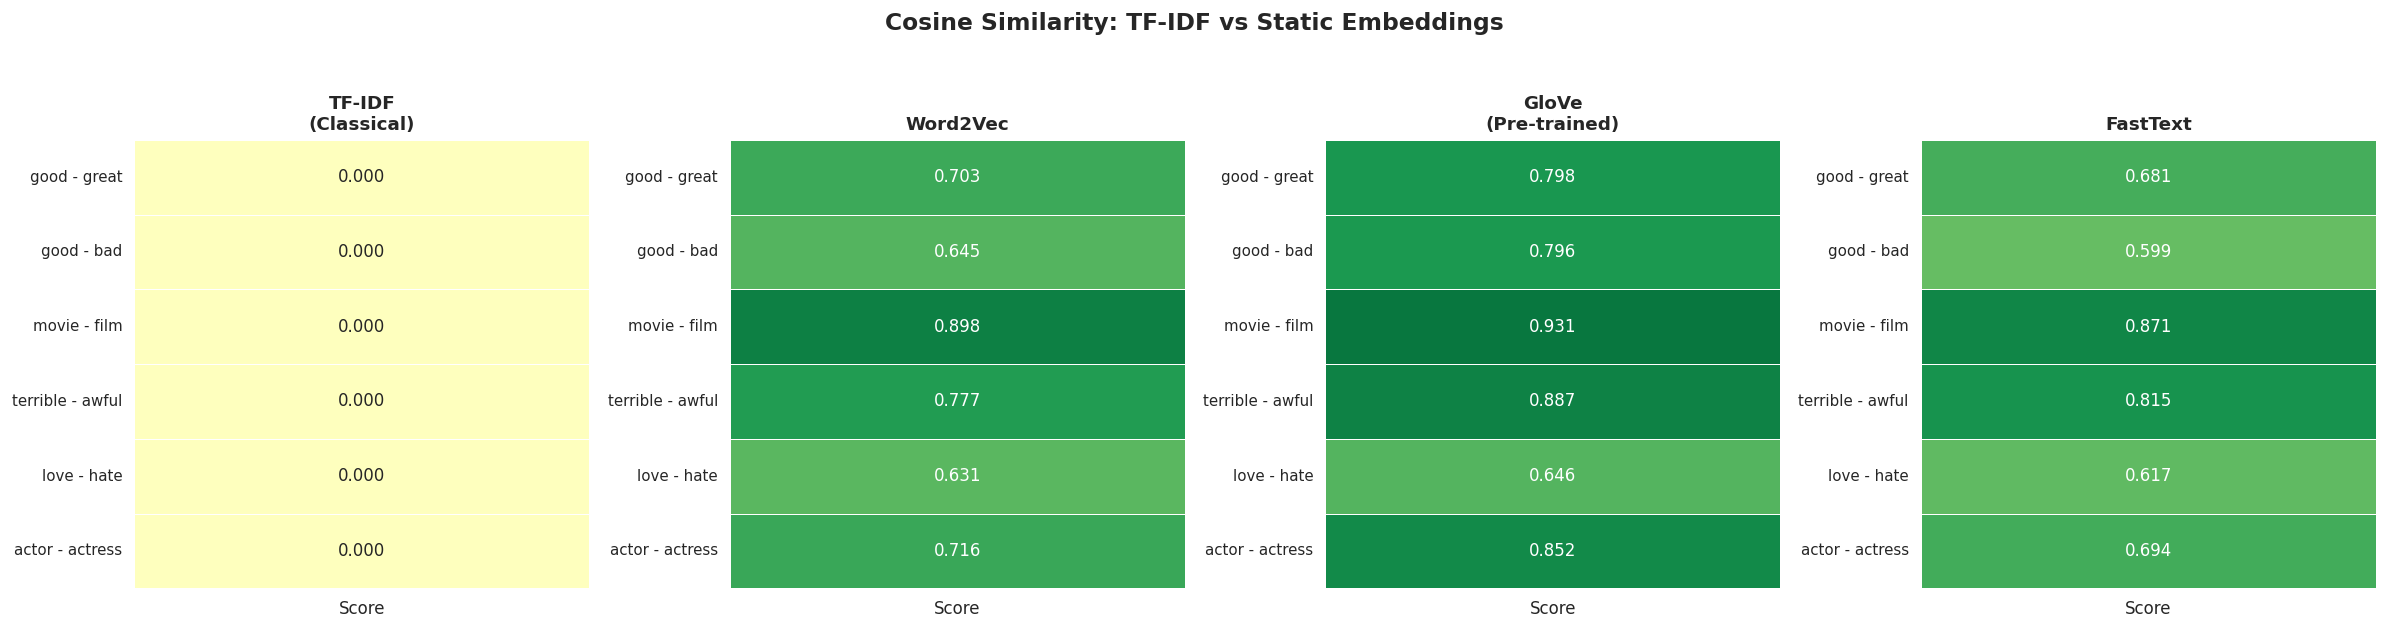

KUNCI: Kolom TF-IDF seragam 0 (semua kata dianggap tidak berhubungan).
       Kolom Embeddings menunjukkan gradasi → kata bermakna mirip skor tinggi.


In [ ]:
# ── Visualisasi: Semantic Similarity Heatmap ────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

methods = {
    'TF-IDF\n(Classical)': sim_df['TF-IDF'],
    'Word2Vec': sim_df['Word2Vec'],
    'GloVe\n(Pre-trained)': sim_df['GloVe'],
    'FastText': sim_df['FastText']
}

for ax, (title, data) in zip(axes, methods.items()):
    matrix = data.values.reshape(-1, 1)
    sns.heatmap(
        matrix,
        annot=True, fmt='.3f',
        yticklabels=sim_df.index,
        xticklabels=['Score'],
        cmap='RdYlGn', vmin=-1, vmax=1,
        ax=ax, cbar=False,
        linewidths=0.5
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Cosine Similarity: TF-IDF vs Static Embeddings',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print("KUNCI: Kolom TF-IDF seragam 0 (semua kata dianggap tidak berhubungan).")
print("       Kolom Embeddings menunjukkan gradasi → kata bermakna mirip skor tinggi.")

In [ ]:
# ── Perbandingan 2: Analogy Tasks ───────────────────────────────────────

extended_analogies = [
    ('king', 'man', 'woman', 'queen'),
    ('good', 'bad', 'worst', 'best'),
    ('actor', 'man', 'woman', 'actress'),
    ('small', 'smaller', 'big', 'bigger'),
]

print("Perbandingan Analogy Tasks:")
print("Formula: a - b + c ≈ ? (target: d)")
print("=" * 75)

analogy_results = []
for a, b, c, target in extended_analogies:
    row = {'Analogy': f"{a} - {b} + {c} = {target}"}

    for name, model in [('Word2Vec', w2v_model.wv), ('GloVe', glove_model), ('FastText', ft_model.wv)]:
        if all(w in model for w in [a, b, c]):
            results = model.most_similar(positive=[a, c], negative=[b], topn=5)
            top_word = results[0][0]
            target_rank = next((i+1 for i, (w,_) in enumerate(results) if w == target), '>5')
            target_score = next((s for w, s in results if w == target), None)

            if top_word == target:
                row[name] = f"BENAR ({target_score:.3f})"
            elif target_score is not None:
                row[name] = f"Rank #{target_rank} ({target_score:.3f}) → Top: {top_word}"
            else:
                row[name] = f"Target tidak di top-5 → Top: {top_word}"
        else:
            row[name] = "OOV"

    row['BoW/TF-IDF'] = "TIDAK MUNGKIN"
    analogy_results.append(row)

analogy_df = pd.DataFrame(analogy_results)
for _, row in analogy_df.iterrows():
    print(f"\n  {row['Analogy']}")
    for col in ['Word2Vec', 'GloVe', 'FastText']:
        print(f"    {col:<12}: {row[col]}")
    print(f"    {'BoW/TF-IDF':<12}: {row['BoW/TF-IDF']}")

Perbandingan Analogy Tasks:
Formula: a - b + c ≈ ? (target: d)

  king - man + woman = queen
    Word2Vec    : BENAR (0.598)
    GloVe       : BENAR (0.852)
    FastText    : Target tidak di top-5 → Top: kings
    BoW/TF-IDF  : TIDAK MUNGKIN

  good - bad + worst = best
    Word2Vec    : BENAR (0.721)
    GloVe       : Target tidak di top-5 → Top: bringing
    FastText    : BENAR (0.683)
    BoW/TF-IDF  : TIDAK MUNGKIN

  actor - man + woman = actress
    Word2Vec    : BENAR (0.784)
    GloVe       : BENAR (0.942)
    FastText    : BENAR (0.813)
    BoW/TF-IDF  : TIDAK MUNGKIN

  small - smaller + big = bigger
    Word2Vec    : Target tidak di top-5 → Top: huge
    GloVe       : Target tidak di top-5 → Top: little
    FastText    : Target tidak di top-5 → Top: biggs
    BoW/TF-IDF  : TIDAK MUNGKIN


In [ ]:
# ── Perbandingan 3: Document Embeddings → Classification ────────────────
#
# Untuk klasifikasi, kita perlu representasi DOKUMEN (bukan kata).
# Pendekatan paling sederhana: rata-rata vektor kata (average pooling)

def document_vector(sentence, model, dim=100):
    """Buat vektor dokumen dari rata-rata word vectors."""
    vectors = []
    for word in sentence:
        if word in model:
            vectors.append(model[word])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)

print("Membuat document vectors...")

# Word2Vec
X_train_w2v = np.array([document_vector(s, w2v_model.wv, 100) for s in train_sentences])
X_test_w2v  = np.array([document_vector(s, w2v_model.wv, 100) for s in test_sentences])

# GloVe
X_train_glove = np.array([document_vector(s, glove_model, 50) for s in train_sentences])
X_test_glove  = np.array([document_vector(s, glove_model, 50) for s in test_sentences])

# FastText
X_train_ft = np.array([document_vector(s, ft_model.wv, 100) for s in train_sentences])
X_test_ft  = np.array([document_vector(s, ft_model.wv, 100) for s in test_sentences])

print(f"  Word2Vec : {X_train_w2v.shape}")
print(f"  GloVe    : {X_train_glove.shape}")
print(f"  FastText : {X_train_ft.shape}")
print("\n Semua dokumen punya representasi DIMENSI TETAP, tidak tergantung vocabulary size!")

Membuat document vectors...
  Word2Vec : (10000, 100)
  GloVe    : (10000, 50)
  FastText : (10000, 100)

 Semua dokumen punya representasi DIMENSI TETAP, tidak tergantung vocabulary size!


In [ ]:
# ── Classification Comparison ────────────────────────────────────────────

embedding_configs = {
    'Word2Vec': (X_train_w2v, X_test_w2v),
    'GloVe': (X_train_glove, X_test_glove),
    'FastText': (X_train_ft, X_test_ft),
}

all_results = dict(classical_results)  # copy classical results

for name, (X_tr, X_te) in embedding_configs.items():
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, train_labels)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(test_labels, y_pred)
    all_results[name] = {
        'accuracy': acc,
        'n_features': X_tr.shape[1],
    }
    print(f"  {name:<22} → Accuracy: {acc:.4f}  ({X_tr.shape[1]:>4} fitur)")

print("\n Catatan penting:")
print("   - Embeddings menggunakan rata-rata vektor kata (sangat sederhana)")
print("   - Fitur yang jauh lebih sedikit (50-100 vs 5,000-10,000)")
print("   - TF-IDF masih kompetitif karena average pooling menghilangkan informasi urutan")
print("   - Embeddings unggul saat digunakan dalam arsitektur deep learning (LSTM, CNN)")

  Word2Vec               → Accuracy: 0.8590  ( 100 fitur)
  GloVe                  → Accuracy: 0.7575  (  50 fitur)
  FastText               → Accuracy: 0.8530  ( 100 fitur)

 Catatan penting:
   - Embeddings menggunakan rata-rata vektor kata (sangat sederhana)
   - Fitur yang jauh lebih sedikit (50-100 vs 5,000-10,000)
   - TF-IDF masih kompetitif karena average pooling menghilangkan informasi urutan
   - Embeddings unggul saat digunakan dalam arsitektur deep learning (LSTM, CNN)


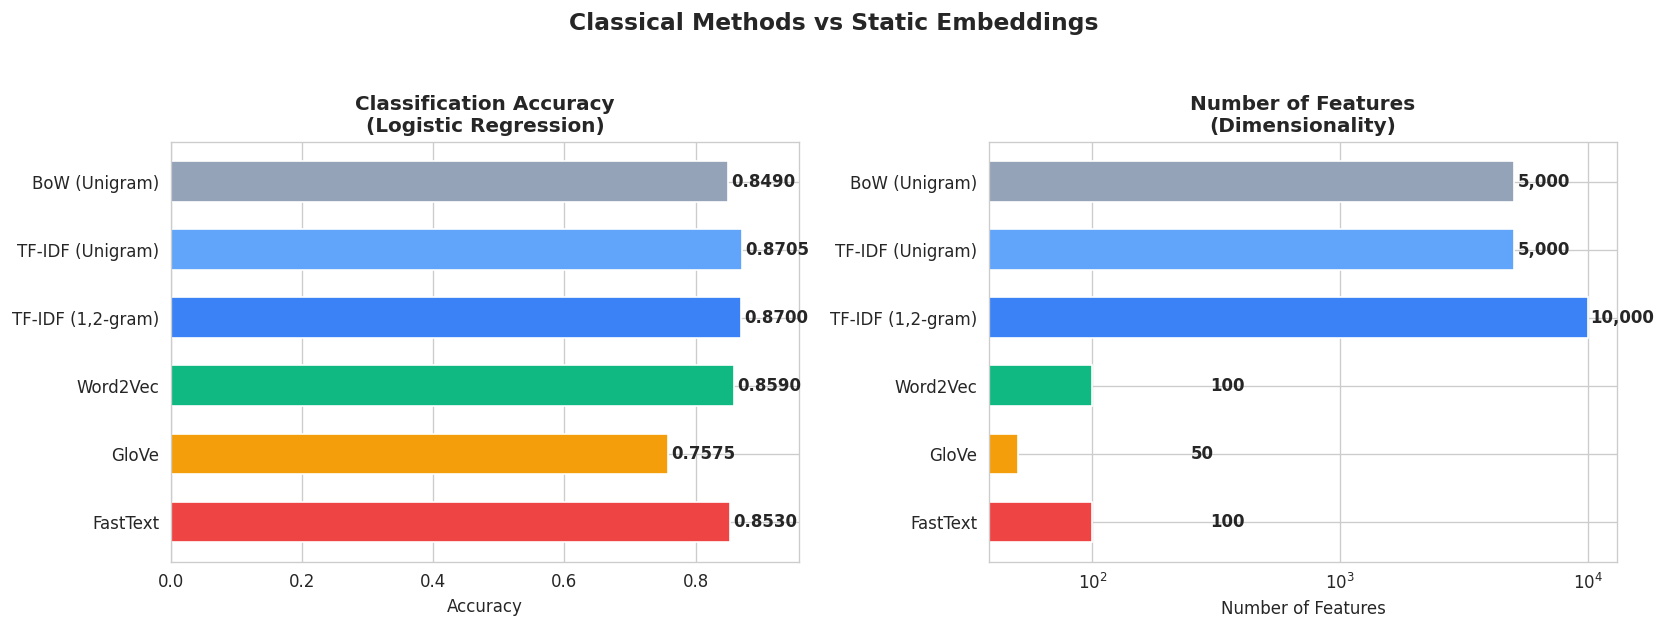

KUNCI:
  - Embeddings menggunakan 50-100x LEBIH SEDIKIT fitur
  - Akurasi masih kompetitif dengan representasi yang jauh lebih kompak
  - Manfaat embeddings lebih terasa pada task yang membutuhkan pemahaman semantik


In [ ]:
# ── Visualisasi: Classification Accuracy Comparison ─────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy
methods = list(all_results.keys())
accuracies = [all_results[m]['accuracy'] for m in methods]
colors = ['#94a3b8', '#60a5fa', '#3b82f6', '#10b981', '#f59e0b', '#ef4444']

bars = ax1.barh(methods, accuracies, color=colors[:len(methods)], edgecolor='white', height=0.6)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontweight='bold', fontsize=10)
ax1.set_xlim(0, max(accuracies) * 1.1)
ax1.set_title('Classification Accuracy\n(Logistic Regression)', fontweight='bold')
ax1.set_xlabel('Accuracy')
ax1.invert_yaxis()

# Plot 2: Number of features (log scale)
n_features = [all_results[m].get('n_features', all_results[m].get('vocab_size', 0)) for m in methods]
bars2 = ax2.barh(methods, n_features, color=colors[:len(methods)], edgecolor='white', height=0.6)
for bar, nf in zip(bars2, n_features):
    ax2.text(bar.get_width() + max(n_features)*0.02, bar.get_y() + bar.get_height()/2,
             f'{nf:,}', va='center', fontweight='bold', fontsize=10)
ax2.set_title('Number of Features\n(Dimensionality)', fontweight='bold')
ax2.set_xlabel('Number of Features')
ax2.set_xscale('log')
ax2.invert_yaxis()

plt.suptitle('Classical Methods vs Static Embeddings',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print("KUNCI:")
print("  - Embeddings menggunakan 50-100x LEBIH SEDIKIT fitur")
print("  - Akurasi masih kompetitif dengan representasi yang jauh lebih kompak")
print("  - Manfaat embeddings lebih terasa pada task yang membutuhkan pemahaman semantik")

In [ ]:
# ── Perbandingan 4: t-SNE Visualization ─────────────────────────────────
#
# Visualisasi 2D dari word embeddings menggunakan t-SNE
# Kata-kata yang bermakna mirip seharusnya berdekatan di plot

# Pilih kata-kata yang relevan untuk sentimen analisis
positive_words = ['good', 'great', 'excellent', 'wonderful', 'amazing', 'best', 'love',
                  'perfect', 'beautiful', 'brilliant', 'fantastic', 'superb']
negative_words = ['bad', 'terrible', 'awful', 'horrible', 'worst', 'hate', 'boring',
                  'waste', 'poor', 'stupid', 'dreadful', 'disappointing']
neutral_words  = ['movie', 'film', 'story', 'plot', 'character', 'scene', 'director',
                  'actor', 'watch', 'time', 'script', 'play']

all_vis_words = positive_words + negative_words + neutral_words

# Filter kata yang ada di semua model
common_words = [w for w in all_vis_words
                if w in w2v_model.wv and w in glove_model and w in ft_model.wv]

print(f"Kata untuk visualisasi: {len(common_words)} (dari {len(all_vis_words)} kandidat)")
print(f"  Positive: {len([w for w in common_words if w in positive_words])}")
print(f"  Negative: {len([w for w in common_words if w in negative_words])}")
print(f"  Neutral : {len([w for w in common_words if w in neutral_words])}")

Kata untuk visualisasi: 36 (dari 36 kandidat)
  Positive: 12
  Negative: 12
  Neutral : 12


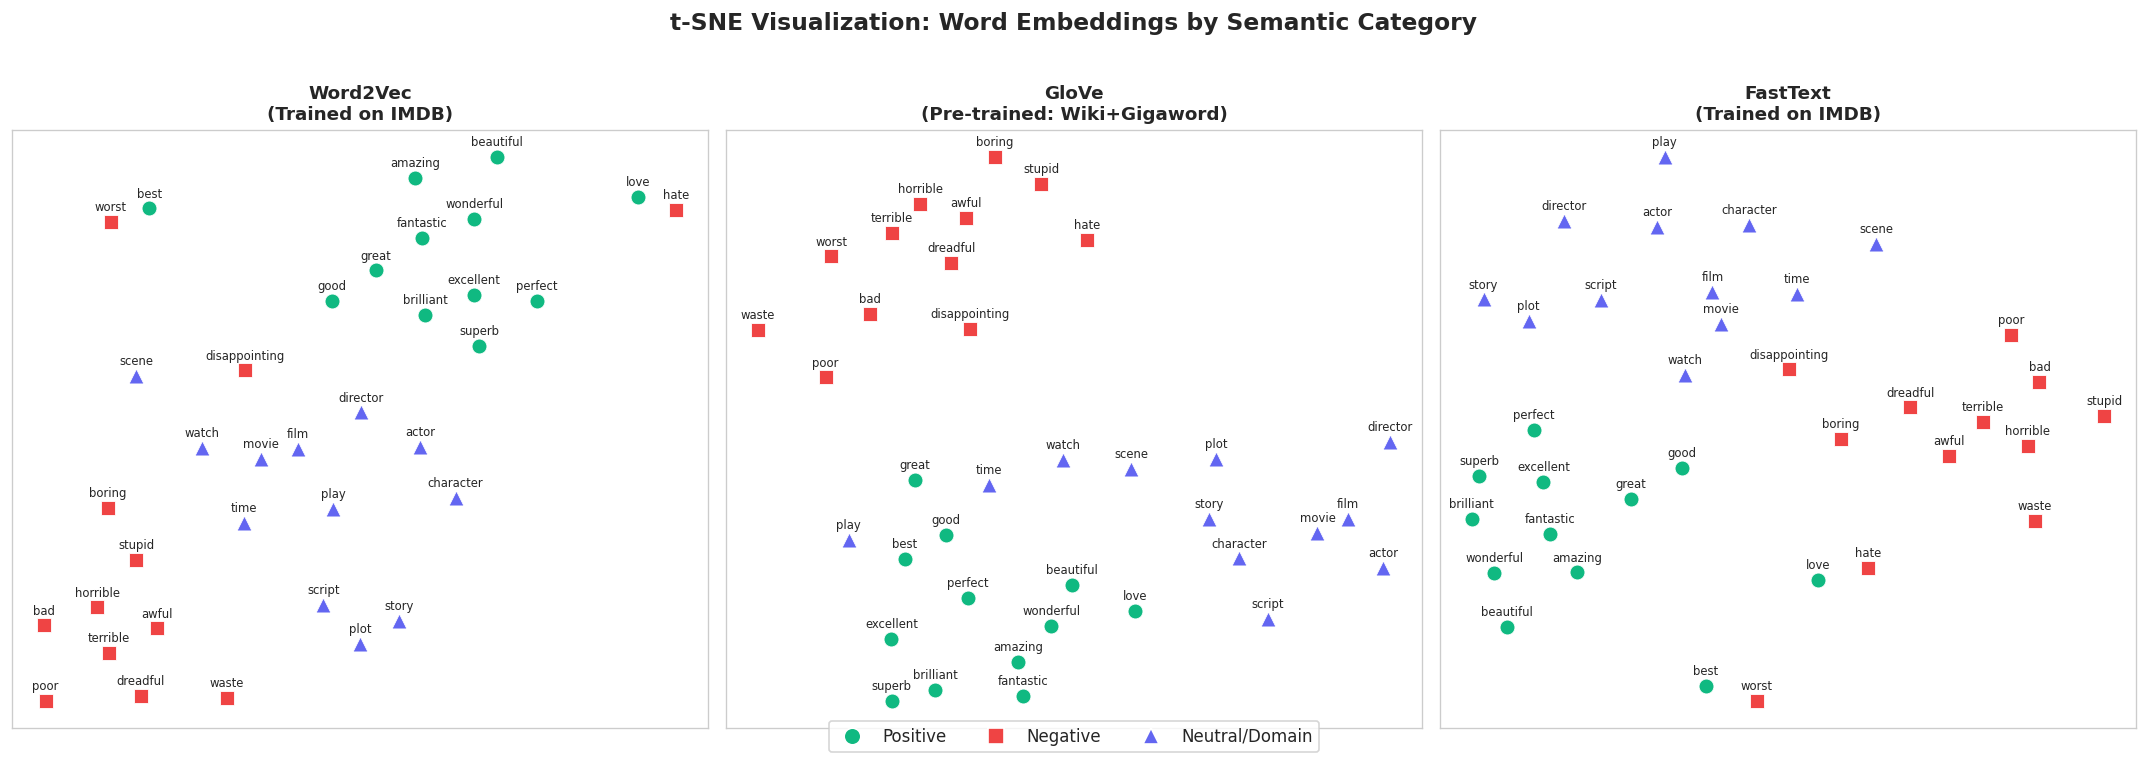

PERHATIKAN:
  - Kata positive (hijau) cenderung BERGELOMBANG bersama
  - Kata negative (merah) juga BERGELOMBANG bersama
  - Kata domain (biru) membentuk kelompok sendiri
  - GloVe (pre-trained) sering menunjukkan pemisahan paling jelas
  - Ini TIDAK BISA divisualisasikan dari BoW/TF-IDF (semua kata orthogonal)


In [ ]:
# ── t-SNE: Word2Vec ─────────────────────────────────────────────────────

def plot_tsne(model, words, title, ax):
    """Plot t-SNE visualization untuk word embeddings."""
    vectors = np.array([model[w] for w in words])

    # Gunakan PCA dulu jika dimensi > 50, lalu t-SNE
    # Cap n_components agar tidak melebihi jumlah samples atau features
    max_pca = min(50, vectors.shape[0], vectors.shape[1])
    if vectors.shape[1] > max_pca:
        pca = PCA(n_components=max_pca, random_state=42)
        vectors_reduced = pca.fit_transform(vectors)
    else:
        vectors_reduced = vectors

    tsne = TSNE(n_components=2, random_state=42, perplexity=min(10, len(words)-1))
    coords = tsne.fit_transform(vectors_reduced)

    # Color berdasarkan kategori
    for i, word in enumerate(words):
        if word in positive_words:
            color = '#10b981'  # green
            marker = 'o'
        elif word in negative_words:
            color = '#ef4444'  # red
            marker = 's'
        else:
            color = '#6366f1'  # indigo
            marker = '^'

        ax.scatter(coords[i, 0], coords[i, 1], c=color, marker=marker,
                   s=80, edgecolors='white', linewidths=0.5, zorder=3)
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

# Plot 3 model berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_tsne(w2v_model.wv, common_words, 'Word2Vec\n(Trained on IMDB)', axes[0])
plot_tsne(glove_model, common_words, 'GloVe\n(Pre-trained: Wiki+Gigaword)', axes[1])
plot_tsne(ft_model.wv, common_words, 'FastText\n(Trained on IMDB)', axes[2])

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#10b981', markersize=10, label='Positive'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#ef4444', markersize=10, label='Negative'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#6366f1', markersize=10, label='Neutral/Domain'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('t-SNE Visualization: Word Embeddings by Semantic Category',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("PERHATIKAN:")
print("  - Kata positive (hijau) cenderung BERGELOMBANG bersama")
print("  - Kata negative (merah) juga BERGELOMBANG bersama")
print("  - Kata domain (biru) membentuk kelompok sendiri")
print("  - GloVe (pre-trained) sering menunjukkan pemisahan paling jelas")
print("  - Ini TIDAK BISA divisualisasikan dari BoW/TF-IDF (semua kata orthogonal)")

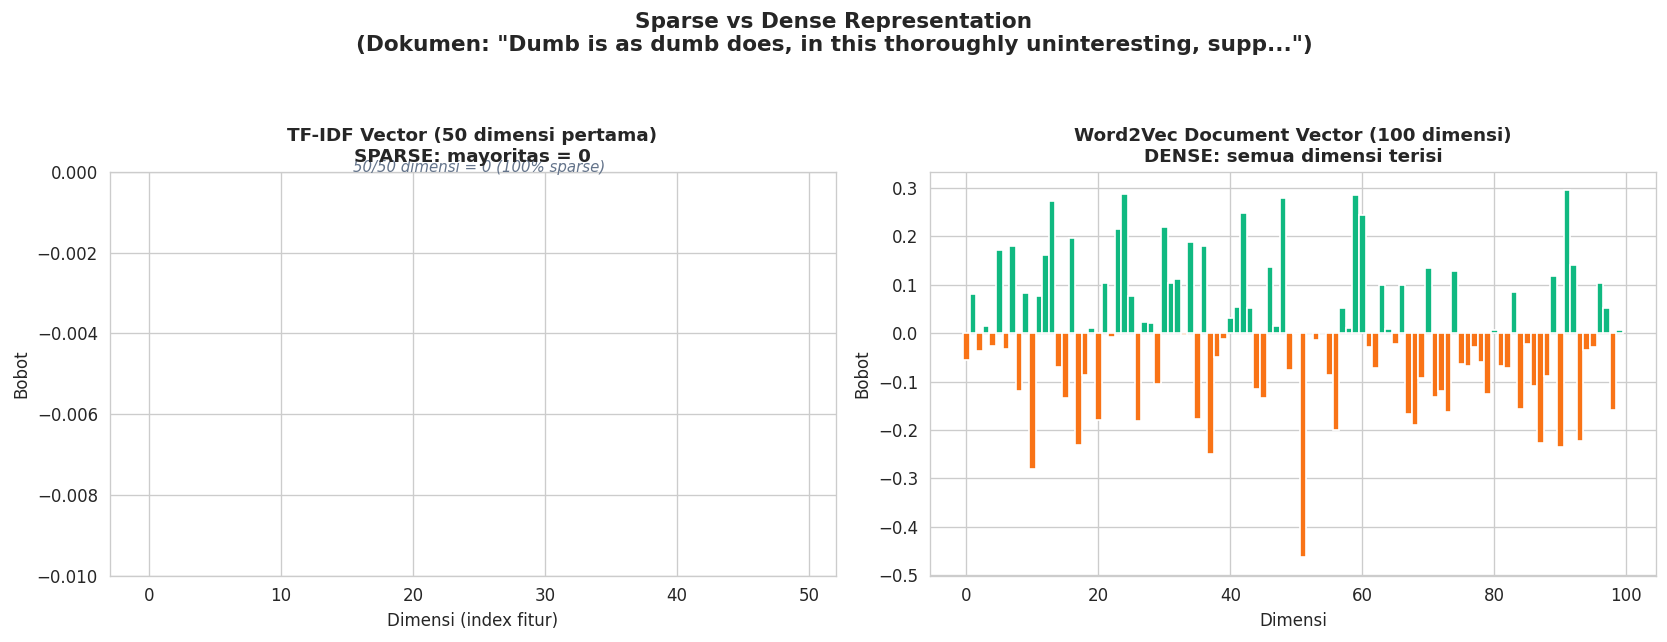


Perbandingan representasi dokumen:
  TF-IDF: 5,000 dimensi, sparsity = 98.7%
  Word2Vec: 100 dimensi, sparsity = 0.0% (DENSE)
  Rasio dimensi: TF-IDF menggunakan 50x LEBIH BANYAK dimensi


In [ ]:
# ── Perbandingan 5: Sparsity & Density ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample dokumen untuk visualisasi
sample_idx = 0
sample_tokens = train_sentences[sample_idx]
sample_tokens_50 = sample_tokens[:50]  # ambil 50 kata pertama

# 1. TF-IDF vector (sparse)
tfidf_sample = configs['TF-IDF (Unigram)']['X_train'][sample_idx].toarray().flatten()
# Ambil 50 fitur pertama untuk visualisasi
tfidf_50 = tfidf_sample[:50]

ax1 = axes[0]
colors_tfidf = ['#3b82f6' if v > 0 else '#e5e7eb' for v in tfidf_50]
ax1.bar(range(50), tfidf_50, color=colors_tfidf, width=1.0, edgecolor='white')
ax1.set_title('TF-IDF Vector (50 dimensi pertama)\nSPARSE: mayoritas = 0',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Dimensi (index fitur)')
ax1.set_ylabel('Bobot')
ax1.set_ylim(-0.01, max(tfidf_50)*1.3)
n_zero = sum(1 for v in tfidf_50 if v == 0)
ax1.text(25, max(tfidf_50)*1.15, f'{n_zero}/50 dimensi = 0 ({n_zero/50*100:.0f}% sparse)',
         ha='center', fontsize=9, color='#64748b', style='italic')

# 2. Word2Vec vector (dense)
w2v_sample = X_train_w2v[sample_idx]
ax2 = axes[1]
colors_w2v = ['#10b981' if v >= 0 else '#f97316' for v in w2v_sample]
ax2.bar(range(len(w2v_sample)), w2v_sample, color=colors_w2v, width=1.0, edgecolor='white')
ax2.set_title(f'Word2Vec Document Vector ({len(w2v_sample)} dimensi)\nDENSE: semua dimensi terisi',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Dimensi')
ax2.set_ylabel('Bobot')

plt.suptitle(f'Sparse vs Dense Representation\n(Dokumen: "{train_df.iloc[sample_idx]["text"][:60]}...")',
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

# Angka-angka perbandingan
tfidf_full_sparsity = 1 - np.count_nonzero(tfidf_sample) / len(tfidf_sample)
print(f"\nPerbandingan representasi dokumen:")
print(f"  TF-IDF: {len(tfidf_sample):,} dimensi, sparsity = {tfidf_full_sparsity*100:.1f}%")
print(f"  Word2Vec: {len(w2v_sample)} dimensi, sparsity = 0.0% (DENSE)")
print(f"  Rasio dimensi: TF-IDF menggunakan {len(tfidf_sample)/len(w2v_sample):.0f}x LEBIH BANYAK dimensi")

In [ ]:
# ── Perbandingan 6: OOV Handling ────────────────────────────────────────

oov_test_words = ['unbelievably', 'blockbuster', 'cinematographically', 'overacting',
                  'heartwarming', 'suspenseful', 'cringeworthy', 'unwatchable']

print("Perbandingan OOV (Out-of-Vocabulary) Handling:")
print("=" * 70)
print(f"{'Kata':<22} {'Word2Vec':<12} {'GloVe':<12} {'FastText':<12}")
print("-" * 70)

oov_stats = {'Word2Vec': 0, 'GloVe': 0, 'FastText': 0}
total = len(oov_test_words)

for word in oov_test_words:
    in_w2v = 'OK' if word in w2v_model.wv else 'OOV'
    in_glove = 'OK' if word in glove_model else 'OOV'
    in_ft = 'OK' if word in ft_model.wv else 'OOV'

    if in_w2v == 'OK': oov_stats['Word2Vec'] += 1
    if in_glove == 'OK': oov_stats['GloVe'] += 1
    if in_ft == 'OK': oov_stats['FastText'] += 1

    print(f"  {word:<20} {in_w2v:<12} {in_glove:<12} {in_ft:<12}")

print("-" * 70)
print(f"  Coverage:            {oov_stats['Word2Vec']}/{total}         {oov_stats['GloVe']}/{total}         {oov_stats['FastText']}/{total}")

print("""
Mengapa FastText unggul dalam OOV?
  'cinematographically' → <cin, ine, nem, ema, mat, tog, gra, rap, aph, ...>
  Subword-subword ini sudah dipelajari dari kata lain ('cinema', 'graphic', dll)
  → FastText bisa menyusun vektor dari potongan-potongan yang sudah dikenal!""")

Perbandingan OOV (Out-of-Vocabulary) Handling:
Kata                   Word2Vec     GloVe        FastText    
----------------------------------------------------------------------
  unbelievably         OK           OK           OK          
  blockbuster          OK           OK           OK          
  cinematographically  OOV          OOV          OK          
  overacting           OK           OK           OK          
  heartwarming         OK           OK           OK          
  suspenseful          OK           OK           OK          
  cringeworthy         OOV          OOV          OK          
  unwatchable          OK           OK           OK          
----------------------------------------------------------------------
  Coverage:            6/8         6/8         8/8

Mengapa FastText unggul dalam OOV?
  'cinematographically' → <cin, ine, nem, ema, mat, tog, gra, rap, aph, ...>
  Subword-subword ini sudah dipelajari dari kata lain ('cinema', 'graphic', dll)
  → Fast